In [3]:
import numpy as np
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_aer import AerSimulator
from qiskit.algorithms.minimum_eigen_solvers import QAOA
from qiskit.algorithms.optimizers import COBYLA
from qiskit.utils import QuantumInstance

quantum_instance = QuantumInstance(AerSimulator())

print("Setup do Qiskit OK!")

C:\Users\Yuri_\AppData\Local\Temp\ipykernel_16612\1208641168.py:9: DeprecationWarning: The class ``qiskit.utils.quantum_instance.QuantumInstance`` is deprecated as of qiskit-terra 0.24.0. It will be removed no earlier than 3 months after the release date. For code migration guidelines, visit https://qisk.it/qi_migration.
  quantum_instance = QuantumInstance(AerSimulator())


Setup do Qiskit OK!


In [5]:
# Criando o problema de otimização com nomes reais de ativos
portfolio = QuadraticProgram()

# Variáveis binárias com nomes dos ativos
ativos = ['VALE', 'PETR4', 'ITUB4']
for ativo in ativos:
    portfolio.binary_var(ativo)

# Função objetivo: retornos esperados de cada ativo
retornos = [0.12, 0.08, 0.10]  # exemplo de retorno esperado
portfolio.maximize(linear={ativos[i]: retornos[i] for i in range(len(ativos))})

# Restrição: escolher no máximo 2 ativos
portfolio.linear_constraint(linear={ativo: 1 for ativo in ativos}, sense='LE', rhs=2, name='budget')

print(portfolio)



maximize 0.1*ITUB4 + 0.08*PETR4 + 0.12*VALE (3 variables, 1 constraints, '')


In [6]:
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit.algorithms.minimum_eigen_solvers import QAOA
from qiskit.algorithms.optimizers import COBYLA
from qiskit.utils import QuantumInstance

# Convertendo para QUBO
qubo_converter = QuadraticProgramToQubo()
qubo = qubo_converter.convert(portfolio)

# Definindo o otimizador e o QAOA
optimizer = COBYLA()
qaoa = QAOA(optimizer=optimizer, reps=1, quantum_instance=QuantumInstance(AerSimulator()))

# Criando o MinimumEigenOptimizer
from qiskit_optimization.algorithms import MinimumEigenOptimizer
meo = MinimumEigenOptimizer(qaoa)

# Rodando a otimização
resultado = meo.solve(qubo)

# Mostrando o resultado
print("Status:", resultado.status)
print("Valor ótimo da função objetivo:", resultado.fval)
print("Distribuição de ativos escolhidos:", resultado.x)


C:\Users\Yuri_\AppData\Local\Temp\ipykernel_16612\4125277628.py:12: DeprecationWarning: The class ``qiskit.utils.quantum_instance.QuantumInstance`` is deprecated as of qiskit-terra 0.24.0. It will be removed no earlier than 3 months after the release date. For code migration guidelines, visit https://qisk.it/qi_migration.
  qaoa = QAOA(optimizer=optimizer, reps=1, quantum_instance=QuantumInstance(AerSimulator()))
C:\Users\Yuri_\AppData\Local\Temp\ipykernel_16612\4125277628.py:12: DeprecationWarning: The class ``qiskit.algorithms.minimum_eigen_solvers.qaoa.QAOA`` is deprecated as of qiskit-terra 0.24.0. It will be removed no earlier than 3 months after the release date. Instead, use the class ``qiskit.algorithms.minimum_eigensolvers.QAOA``. See https://qisk.it/algo_migration for a migration guide.
  qaoa = QAOA(optimizer=optimizer, reps=1, quantum_instance=QuantumInstance(AerSimulator()))


Status: OptimizationResultStatus.SUCCESS
Valor ótimo da função objetivo: -0.22000000000000064
Distribuição de ativos escolhidos: [1. 0. 1. 0. 0.]


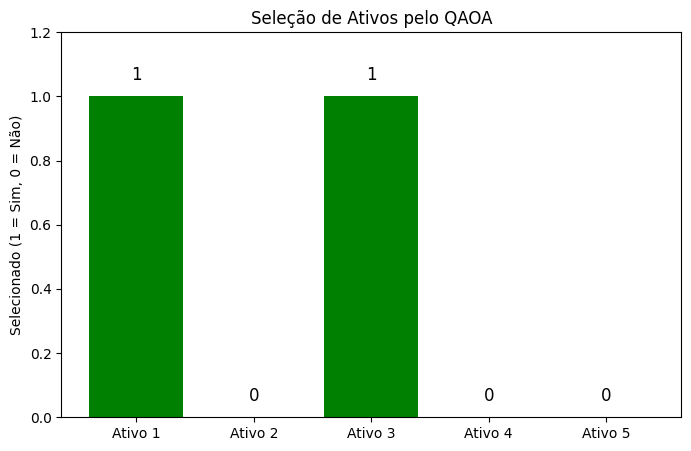

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Nomes dos ativos
ativos = ["Ativo 1", "Ativo 2", "Ativo 3", "Ativo 4", "Ativo 5"]

# Resultado do QAOA (1 = escolhido, 0 = não escolhido)
escolhidos = np.array([1, 0, 1, 0, 0])

# Criar gráfico
plt.figure(figsize=(8,5))
plt.bar(ativos, escolhidos, color=['green' if x==1 else 'gray' for x in escolhidos])
plt.title("Seleção de Ativos pelo QAOA")
plt.ylabel("Selecionado (1 = Sim, 0 = Não)")
plt.ylim(0,1.2)
for i, val in enumerate(escolhidos):
    plt.text(i, val + 0.05, str(val), ha='center', fontsize=12)
plt.show()


In [18]:
import numpy as np
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo

# Exemplo de dados
ativos = ["A", "B", "C", "D", "E"]
retornos = np.array([0.1, 0.2, 0.15, 0.05, 0.12])
cov_matrix = np.array([
    [0.005, -0.010, 0.004, -0.002, 0.001],
    [-0.010, 0.040, -0.002, 0.004, -0.001],
    [0.004, -0.002, 0.023, 0.002, 0.003],
    [-0.002, 0.004, 0.002, 0.018, -0.002],
    [0.001, -0.001, 0.003, -0.002, 0.010]
])

# Criar QuadraticProgram
qp = QuadraticProgram(name="portfolio")
for ativo in ativos:
    qp.binary_var(name=ativo)

# Função objetivo: minimizar risco - retorno ponderado
lambda_risco = 0.5
linear = -retornos  # queremos maximizar retorno
quadratic = lambda_risco * cov_matrix

qp.minimize(linear=linear, quadratic=quadratic)

# Converter para QUBO
qubo = QuadraticProgramToQubo().convert(qp)
print("QUBO criado com sucesso!")


QUBO criado com sucesso!


In [20]:
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo

# Criar programa quadrático
qp = QuadraticProgram(name="portfolio")

# Variáveis binárias
for ativo in ativos:
    qp.binary_var(name=ativo)

# Função objetivo: minimizar risco - retorno ponderado
lambda_risco = 0.5

# Montar o termo de risco (quadrático)
for i in range(len(ativos)):
    for j in range(len(ativos)):
        qp.minimize(quadratic={(i,j): lambda_risco * cov_matrix[i,j]})

# Montar o termo de retorno (linear)
linear_terms = {i: -retornos[i] for i in range(len(ativos))}
qp.minimize(linear=linear_terms)



In [23]:
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit.algorithms import QAOA  # QAOA da versão 0.43.3
from qiskit.algorithms.optimizers import COBYLA
from qiskit_aer import AerSimulator
from qiskit.utils import QuantumInstance

# Criar simulador
simulator = AerSimulator()

# Criar instância quântica
quantum_instance = QuantumInstance(simulator)

# Otimizador clássico
optimizer = COBYLA()

# Criar QAOA
qaoa = QAOA(optimizer=optimizer, reps=1, quantum_instance=quantum_instance)

# Conectar QAOA com o problema quântico
meo = MinimumEigenOptimizer(qaoa)

# Resolver
result = meo.solve(qubo)

# Mostrar resultado
print("Status:", result.status)
print("Valor ótimo da função objetivo:", result.fval)
print("Distribuição de ativos escolhidos:", result.x)


C:\Users\Yuri_\AppData\Local\Temp\ipykernel_16612\3340266850.py:11: DeprecationWarning: The class ``qiskit.utils.quantum_instance.QuantumInstance`` is deprecated as of qiskit-terra 0.24.0. It will be removed no earlier than 3 months after the release date. For code migration guidelines, visit https://qisk.it/qi_migration.
  quantum_instance = QuantumInstance(simulator)
C:\Users\Yuri_\AppData\Local\Temp\ipykernel_16612\3340266850.py:17: DeprecationWarning: The class ``qiskit.algorithms.minimum_eigen_solvers.qaoa.QAOA`` is deprecated as of qiskit-terra 0.24.0. It will be removed no earlier than 3 months after the release date. Instead, use the class ``qiskit.algorithms.minimum_eigensolvers.QAOA``. See https://qisk.it/algo_migration for a migration guide.
  qaoa = QAOA(optimizer=optimizer, reps=1, quantum_instance=quantum_instance)


Status: OptimizationResultStatus.SUCCESS
Valor ótimo da função objetivo: -0.6200000000000001
Distribuição de ativos escolhidos: [1. 1. 1. 1. 1.]


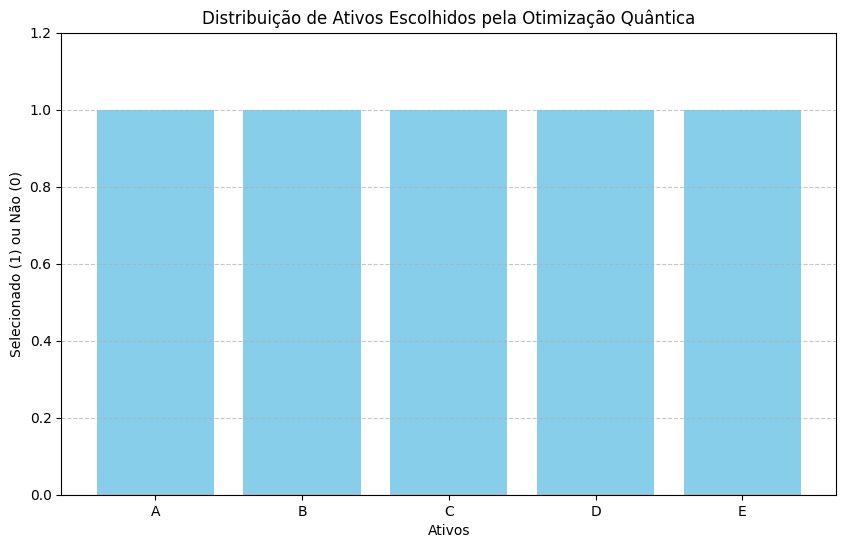

In [24]:
import matplotlib.pyplot as plt

# Distribuição de ativos escolhidos
escolhidos = result.x

# Criar gráfico de barras
plt.figure(figsize=(10,6))
plt.bar(ativos, escolhidos, color='skyblue')
plt.title("Distribuição de Ativos Escolhidos pela Otimização Quântica")
plt.ylabel("Selecionado (1) ou Não (0)")
plt.xlabel("Ativos")
plt.ylim(0, 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [25]:
import yfinance as yf
import numpy as np
from qaoa_portfolio import PortfolioInstance, solve_qaoa, solve_classical_bruteforce

# 1️⃣ Selecionar tickers
tickers = ["PETR4.SA", "VALE3.SA", "ITUB4.SA", "ABEV3.SA"]

# 2️⃣ Puxar cotações históricas
prices = yf.download(tickers, start="2023-01-01", end="2025-08-20")["Adj Close"]

# 3️⃣ Calcular retornos diários e estatísticas
returns = prices.pct_change().dropna()
mu = returns.mean().values
Sigma = returns.cov().values

# 4️⃣ Criar instância do portfólio
inst = PortfolioInstance(tickers=tickers, mu=mu, Sigma=Sigma, budget=2, risk_aversion=0.5)

# 5️⃣ Rodar QAOA
qaoa_res = solve_qaoa(inst, reps=2)

# 6️⃣ Rodar baseline clássico
classic_res = solve_classical_bruteforce(inst)

# 7️⃣ Mostrar resultados
print("=== Resultados QAOA ===")
print("Selecionados:", qaoa_res["tickers_selected"])
print("x*:", qaoa_res["x"])
print("Objetivo:", qaoa_res["objective"])

print("\n=== Resultados Clássicos ===")
print("Selecionados:", classic_res["tickers_selected"])
print("x*:", classic_res["x"])
print("Objetivo:", classic_res["objective"])


ModuleNotFoundError: No module named 'qaoa_portfolio'